★実行環境の選択

In [49]:
# VSCodeの場合
# edi_flg = 1
# Googlre Colabの場合
edi_flg = 0

In [50]:
import os

repo_path = "/content/My_Python_project"

if edi_flg == 0:
  # GoogleColabにGitHubリポジトリがクローンされていなければ
  # GoogleColabにGitHubリポジトリをクローンする用
  if not os.path.exists(repo_path):
    %cd /content/My_Python_project
    !git clone https://github.com/keiseki-eng/My_Python_project.git
    !git pull origin main



In [51]:
# import sys
# !{sys.executable} -m pip install ipykernel

In [52]:
if edi_flg == 0:
    !pip install japanize-matplotlib

import os
import sys
import yaml
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import shap
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
import japanize_matplotlib #日本語表示対応
from sklearn.model_selection import KFold
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error


# Notebook から src ディレクトリを追加
# sys.path.append(os.path.join(os.getcwd(), "src"))
sys.path.append("/home/keiseki/My_Python_project/src")

In [53]:
if edi_flg == 0:
  from google.colab import drive
  drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=pd.errors.PerformanceWarning
)

## 01.config読み込み

In [55]:
# VSCode用
if edi_flg==1:
  conf_path = os.path.join( '../config/config.yaml')
  with open(conf_path, 'r') as f:
    config = yaml.safe_load(f)

# GoogleColab用
elif edi_flg==0:
  conf_path = "My_Python_project/config/含水率判定/config.yaml"
  with open(conf_path, "r") as f:
    config = yaml.safe_load(f)

In [56]:
# 定義した特徴量リストを読み込み
feature_list = config['FEATURE']['FEATURE_LIST']

In [57]:
# カテゴリカルカラムのリストを定義
categorical_cols = config['FEATURE']['CATEGORICAL_COLS']

## 02.データ読み込み

In [58]:
# VSCode用
if edi_flg==1:
# ドライブ内のファイルパスを指定
    train_path = '../20.Data/含水率判定/preprocessed_train.pkl'
    df_train = pd.read_pickle(train_path)

# GoogleColab用
elif edi_flg==0:
    # GoogleDriveをマウントしてファイル読み込み準備
    from google.colab import drive
    drive.mount('/content/drive')
    # ドライブ内のファイルパスを指定
    train_path = '/content/My_Python_project/20.Data/含水率判定/preprocessed_train.pkl'
    df_train = pd.read_pickle(train_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
# testデータの読み込み
# VSCode用
if edi_flg==1:
    test_path = '../20.Data/含水率判定/preprocessed_test.pkl'
    df_test = pd.read_pickle(test_path)

# GoogleColab用
elif edi_flg==0:
    # ドライブ内のファイルパスを指定
    test_path = '/content/My_Python_project/20.Data/含水率判定/preprocessed_test.pkl'
    df_test = pd.read_pickle(test_path)

In [60]:
# スペクトル平均などの特徴量作成

# 数値列だけ取得
num_cols = df_train.select_dtypes(include="number").columns
# 指定特徴量だけ除外
# num_cols = num_cols.drop(["含水率", "sample number", "密度", "針葉樹"])
num_cols = num_cols.drop(["含水率", "sample number", "密度"])

spec_cols = num_cols  # スペクトル列

df_train["spec_mean"] = df_train[spec_cols].mean(axis=1)
df_train["spec_std"] = df_train[spec_cols].std(axis=1)
df_train["spec_max"] = df_train[spec_cols].max(axis=1)
df_train["spec_min"] = df_train[spec_cols].min(axis=1)

df_test["spec_mean"] = df_test[spec_cols].mean(axis=1)
df_test["spec_std"] = df_test[spec_cols].std(axis=1)
df_test["spec_max"] = df_test[spec_cols].max(axis=1)
df_test["spec_min"] = df_test[spec_cols].min(axis=1)

# 特徴量リストに追加
# feature_list = feature_list + ["spec_mean", "spec_std", "spec_max", "spec_min"]

In [61]:
# 水吸収と関係の深い周波数帯を作成
df_train["water_band_5200"] = df_train.loc[:, "5303.52402": "5102.95438",].mean(axis=1)
df_train["water_band_6900"] = df_train.loc[:,  "7000.65171":"6800.08207"].mean(axis=1)
df_train["water_band_8300"] = df_train.loc[:, "8400.78205":"8200.21241"].mean(axis=1)

df_test["water_band_5200"] = df_test.loc[:, "5303.52402": "5102.95438",].mean(axis=1)
df_test["water_band_6900"] = df_test.loc[:,  "7000.65171":"6800.08207"].mean(axis=1)
df_test["water_band_8300"] = df_test.loc[:, "8400.78205":"8200.21241"].mean(axis=1)

# feature_list = feature_list + ["water_band_5200", "water_band_6900", "water_band_8300"]

In [62]:
# 経過時間特徴量を樹種ごとに設定
df_train["経過時間"] = df_train.groupby("樹種").cumcount()
df_test["経過時間"] = df_test.groupby("樹種").cumcount()

# feature_list = feature_list + ["経過時間"]

## 05.train/valid 分割　＆　target加工

In [63]:
# スペクトル列
num_cols = df_train.select_dtypes(include="number").columns
# 指定特徴量だけ除外
num_cols = num_cols.drop(["含水率", "species number", "sample number", "密度"])



# スペクトル微分特徴量
df_train_diff = df_train[num_cols].diff(axis=1)
df_test_diff = df_test[num_cols].diff(axis=1)

df_train_diff.columns = [f"diff_{c}" for c in num_cols]
df_test_diff.columns = [f"diff_{c}" for c in num_cols]

df_train = pd.concat([df_train, df_train_diff], axis=1)
df_test = pd.concat([df_test, df_test_diff], axis=1)



In [64]:
from sklearn.decomposition import PCA

# NaNを埋める
df_train[num_cols] = df_train[num_cols].fillna(0)
df_test[num_cols] = df_test[num_cols].fillna(0)

# PCA
pca = PCA(n_components=30, random_state=42)

train_pca = pca.fit_transform(df_train[num_cols])
test_pca = pca.transform(df_test[num_cols])

pca_cols = [f"pca_{i}" for i in range(30)]

train_pca = pd.DataFrame(train_pca, columns=pca_cols)
test_pca = pd.DataFrame(test_pca, columns=pca_cols)

df_train = pd.concat([df_train, train_pca], axis=1)
df_test = pd.concat([df_test, test_pca], axis=1)

In [65]:
diff_cols = [c for c in df_train.columns if "diff_" in c]

# NaNを埋める
df_train[diff_cols] = df_train[diff_cols].fillna(0)
df_test[diff_cols] = df_test[diff_cols].fillna(0)


pca_diff = PCA(n_components=30, random_state=42)

train_pca_diff = pca_diff.fit_transform(df_train[diff_cols])
test_pca_diff = pca_diff.transform(df_test[diff_cols])

pca_diff_cols = [f"pca_diff_{i}" for i in range(30)]

train_pca_diff = pd.DataFrame(train_pca_diff, columns=pca_diff_cols)
test_pca_diff = pd.DataFrame(test_pca_diff, columns=pca_diff_cols)

df_train = pd.concat([df_train, train_pca_diff], axis=1)
df_test = pd.concat([df_test, test_pca_diff], axis=1)

In [66]:


# # rawスペクトル削除
# df_train = df_train.drop(columns=num_cols)
# df_test = df_test.drop(columns=num_cols)

# # diffスペクトル削除
# df_train = df_train.drop(columns=diff_cols)
# df_test = df_test.drop(columns=diff_cols)

In [67]:
# X_all, X_train, X_validの再構築
X_all = df_train.drop(columns=["含水率"])
y_all = df_train["含水率"]



# X_train, X_valid, y_train, y_valid = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
gkf = GroupKFold(n_splits=5)
cat_cols = ["species number", "樹種", "科目"]
# LightGBM のパラメータ設定
params = config['MODEL_PARAMS']

groups = df_train["樹種"]

scores = []

test_preds = np.zeros(len(df_test))

for fold, (train_idx, valid_idx) in enumerate(gkf.split(X_all, y_all, groups)):

    X_train = X_all.iloc[train_idx].copy()
    X_valid = X_all.iloc[valid_idx].copy()

    y_train = y_all.iloc[train_idx]
    y_valid = y_all.iloc[valid_idx]

    for c in cat_cols:
        X_train[c] = X_train[c].astype("category")

        X_valid[c] = pd.Categorical(
            X_valid[c],
            categories=X_train[c].cat.categories
        )
        df_test[c] = pd.Categorical(
            df_test[c],
            categories=X_train[c].cat.categories
        )

    lgb_train = lgb.Dataset(
        X_train,
        y_train,
        categorical_feature=cat_cols
    )

    lgb_valid = lgb.Dataset(
        X_valid,
        y_valid,
        reference=lgb_train,
        categorical_feature=cat_cols
    )

    model = lgb.train(
        params,
        lgb_train,
        valid_sets=[lgb_valid],
        # feval=mape_eval,
        callbacks=[lgb.early_stopping(200)]
    )


    y_pred = model.predict(X_valid)



    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    print("fold", fold, "RMSE:", rmse)

    scores.append(rmse)

    # test予測を平均
    test_preds += model.predict(df_test) / gkf.n_splits

print("CV:", np.mean(scores))

Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[96]	valid_0's rmse: 15.4091
fold 0 RMSE: 15.409050773979978
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 13.06
fold 1 RMSE: 13.06003842559179
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[85]	valid_0's rmse: 39.4164
fold 2 RMSE: 39.41643528890707
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[99]	valid_0's rmse: 14.7208
fold 3 RMSE: 14.720796029624656
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[70]	valid_0's rmse: 9.9556
fold 4 RMSE: 9.95560419263213
CV: 18.512384942147122


## 06.樹種カラム他をカテゴリデータ化

In [68]:
# cat_cols = ["species number", "樹種", "科目"]
# # cat_cols = ["科目"]

# for c in cat_cols:
#     X_train[c] = X_train[c].astype("category")

#     X_valid[c] = pd.Categorical(
#         X_valid[c],
#         categories=X_train[c].cat.categories
#     )

#     df_test[c] = pd.Categorical(
#         df_test[c],
#         categories=X_train[c].cat.categories
#     )

## 07.モデル学習

In [69]:
# # LightGBM のパラメータ設定
# params = config['MODEL_PARAMS']

# # LightGBM のデータセットを作成
# lgb_train = lgb.Dataset(
#     X_train,
#     y_train,
#     # weight=w_train,
#     categorical_feature=categorical_cols
# )


# lgb_test = lgb.Dataset(
#     X_valid,
#     y_valid,
#     reference=lgb_train,
#     categorical_feature=categorical_cols
# )

In [70]:
# # モデルの学習
# model = lgb.train(params,
#                   lgb_train,
#                   valid_sets=[lgb_train, lgb_test],
#                   feval=mape_eval,  # ← カスタム評価関数を指定
#                   callbacks=[lgb.early_stopping(stopping_rounds=1000, verbose=False)
#                   ]) #early_stoppingあり

## 08.評価

特徴量の重要度


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

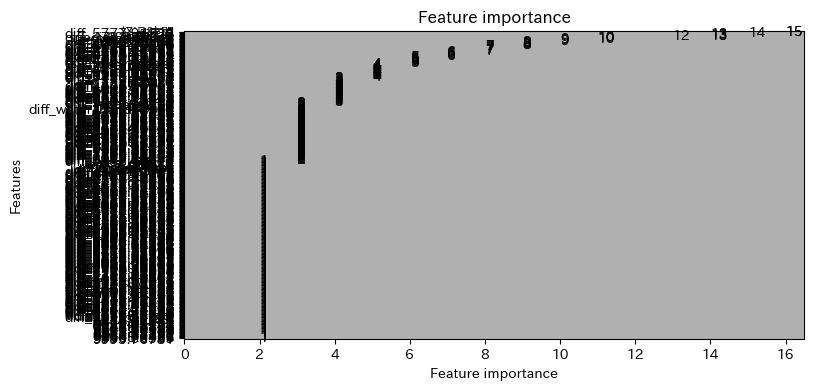

In [71]:
# テストデータで予測
y_pred = model.predict(X_valid , num_iteration=model.best_iteration)


# 特徴量の重要度
print("特徴量の重要度")
lgb.plot_importance(model, figsize=(8,4))


## 09.可視化（importance SHAP）

In [72]:
#SHAP値の取得
explainer = shap.TreeExplainer(model=model)#SHAP値を取得するためのモデル作成
shap_values = explainer.shap_values(X=X_valid)#説明変数それぞれの値のSHAP値を取得する

# print(shap_values)
# print(shap_values.shape)


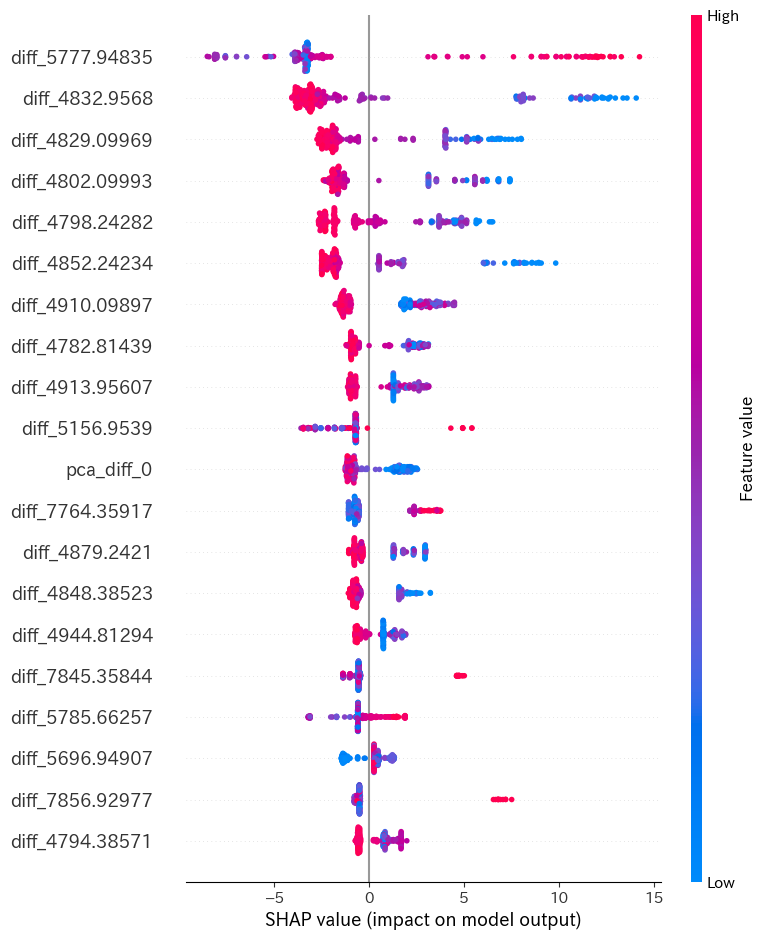

In [73]:

# 変数別の影響度の可視化
shap.initjs()
# shap.summary_plot(shap_values, X_valid, plot_type="bar", show=False)
shap.summary_plot(shap_values, X_valid, show=False)


# 0番目のデータポイントを再選択
i = 0
single_observation = X_valid.iloc[i:i+1,:]


#print(single_observation)


# Explainerを使って説明を再計算
# single_shap_values = explainer(single_observation)

# waterfallプロットの生成
# shap.waterfall_plot(single_shap_values[0])

## 10.推論、提出

## 提出用データの作成

# ★テストデータと学習データで樹種が全然違うから、ワンホットエンコーディングの結果のカラムが違うんだ！　⇨　とりあえずベースラインではconfigでワンホットエンコーディングを消しとこう・・・

In [74]:
# df_trainとdf_testのカラムの差分を確認したい
train_cols = set(X_train.columns)
test_cols  = set(df_test.columns)

# trainにあってtestにない
print("Only in train:")
print(train_cols - test_cols)

# testにあってtrainにない
print("\nOnly in test:")
print(test_cols - train_cols)

Only in train:
set()

Only in test:
set()


In [75]:
# 特徴量の選定
# df_test_p = df_test[feature_list].copy()

# 予測
y_scores_submit = test_preds

# print(y_scores_submit)

In [76]:
#提出用csvの作成
df_scores_submit = pd.DataFrame(y_scores_submit)
df_submit = pd.concat([df_test["sample number"], df_scores_submit], axis=1)

df_submit.to_csv("submit.csv", index=False, header=False)



## 誤差要因分析

In [77]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<Axes: ylabel='Frequency'>

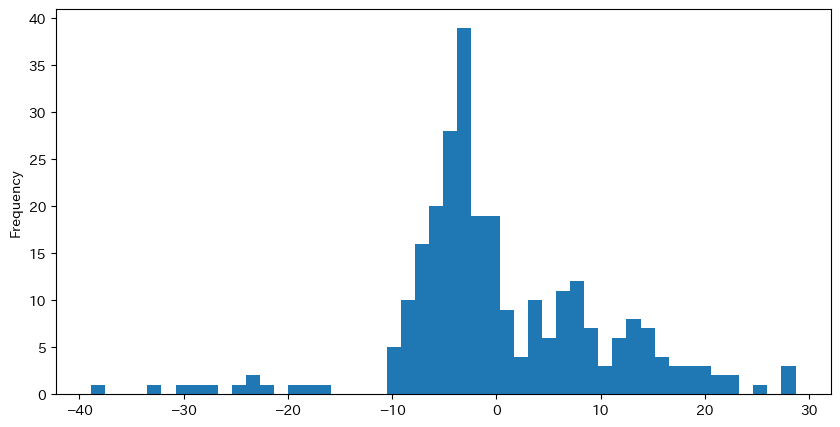

In [78]:
# valid予測
y_pred_valid = model.predict(X_valid, num_iteration=model.best_iteration)


df_eval = X_valid.copy()
df_eval["y_true"] = y_valid
df_eval["y_pred"] = y_pred_valid

# APE計算（0割防止）
df_eval["ape"] = np.abs(df_eval["y_true"] - df_eval["y_pred"]) / np.maximum(df_eval["y_true"], 1e-7)

# 上位ワースト確認
# df_eval.sort_values("ape", ascending=False).head(20)
df_eval["スコア差分"] = df_eval["y_true"] - df_eval["y_pred"]
df_eval["スコア差分"].plot.hist(bins=50, figsize=(10,5))

In [79]:
def compare_distribution(col):
    return pd.DataFrame({
        "train": df_train[col].describe(),
        "valid": X_valid[col].describe()
    })

# compare_distribution("money_rimawari_now")


In [80]:
# APEが大きい上位10%
threshold = df_eval["ape"].quantile(0.9)
bad_samples = df_eval[df_eval["ape"] >= threshold]

# SHAP値抽出
shap_values_valid = explainer.shap_values(X_valid)
shap_df = pd.DataFrame(
    shap_values_valid,
    columns=X_valid.columns,
    index=X_valid.index
)


# 悪いサンプルのSHAP平均
shap_df.loc[bad_samples.index].abs().mean().sort_values(ascending=False).head(10)


,0
diff_5777.94835,3.873155
diff_4832.9568,3.743919
diff_4829.09969,2.471366
diff_4852.24234,2.424091
diff_4798.24282,2.376696
diff_4802.09993,1.931051
diff_4910.09897,1.430390
diff_4493.53126,1.376319
diff_5696.94907,1.272575
pca_diff_0,1.100512


In [81]:
# shap.force_plot(base_value=explainer.expected_value, shap_values=shap_values, features=X_train)

In [82]:
def calc_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-7))) * 100


# valid 予測
y_pred_valid = model.predict(X_valid, num_iteration=model.best_iteration)


# MAPE 出力
valid_mape = calc_mape(y_valid, y_pred_valid)
print(f"VALID MAPE: {valid_mape:.4f}%")


VALID MAPE: 39.0307%


In [83]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# df_eval = X_valid.copy()
# df_eval["unit_area"] = np.expm1(df_eval["unit_area"])
# df_eval["y_true"] = y_valid
# df_eval["y_pred"] = y_pred_valid
# df_eval["ape"] = np.abs(df_eval["y_true"] - df_eval["y_pred"]) / np.maximum(df_eval["y_true"], 1e-7)

# # 上位10%の誤差サンプル抽出
# threshold = df_eval["ape"].quantile(0.9)
# bad_samples = df_eval[df_eval["ape"] >= threshold]

# # 調査対象の特徴量リスト
# check_features = [
#     "unit_area",
#     "post1",
#     "floor_plan_code",
#     "walk_distance1",
#     "walk_distance2",
# ]

# # タグ系カラムを抽出（feature_list に基づく）
# tag_features = [col for col in feature_list if col.startswith("tag_")]
# check_features.extend(tag_features)

# # 1. 数値特徴量の誤差 vs 値域の関係
# num_features = ["unit_area", "walk_distance1", "walk_distance2"]
# for col in num_features:
#     plt.figure(figsize=(8,4))
#     sns.scatterplot(data=df_eval, x=col, y="ape", alpha=0.3)
#     sns.scatterplot(data=bad_samples, x=col, y="ape", color="red", alpha=0.5)
#     plt.title(f"{col} と予測誤差(APE)の関係")
#     plt.ylabel("APE")
#     plt.xlabel(col)
#     plt.show()

# # 2. カテゴリ特徴量の誤差分布（箱ひげ図）
# cat_features = ["post1", "floor_plan_code"]
# for col in cat_features:
#     plt.figure(figsize=(10,4))
#     sns.boxplot(x=col, y="ape", data=df_eval)
#     plt.title(f"{col} ごとの予測誤差(APE)分布")
#     plt.xticks(rotation=45)
#     plt.show()

# # 3. タグ系特徴量の影響（悪いサンプルと全体比較）
# for col in tag_features:
#     if col not in df_eval.columns:
#         continue
#     mean_all = df_eval[col].mean()
#     mean_bad = bad_samples[col].mean()
#     print(f"{col}: 全体平均={mean_all:.3f}, 誤差上位10%平均={mean_bad:.3f}")
